In [1]:
from pathlib import Path
from torch import multiprocessing
from tqdm import tqdm
import soundfile as sf

In [2]:
import numpy as np
import pandas as pd
import time

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

In [4]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from utils.utils import gen_empty_df
from cfg import get_config

In [5]:
def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_annotations_df,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])
        
    return bd_dets

def apply_models(file_path_mappings, cfg):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a dataframe

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()
    cfg : `dict`
        - A dictionary of pipeline parameters:
        - models is the models in the pipeline that are being used.

    Returns
    ------------
    bd_preds : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    process_pool = multiprocessing.Pool(cfg['num_processes'])

    bd_dets = tqdm(
            process_pool.imap(apply_model, file_path_mappings, chunksize=1), 
            desc=f"Applying BatDetect2",
            total=len(file_path_mappings),
        )
    
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(bd_dets, ignore_index=True)
    
    return bd_preds

def apply_model(file_mapping):
    """
    Runs the batdetect2 model on a single provided audio segmens and corrects the offsets according the segment.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    corrected_bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = file_mapping['model']._run_batdetect(file_mapping['audio_seg']['audio_file'])
    corrected_bd_dets = pipeline._correct_annotation_offsets(
                                                            bd_dets,
                                                            file_mapping['original_file_name'],
                                                            file_mapping['audio_seg']['offset']
                                                            )

    return corrected_bd_dets

In [6]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = run_models(file_path_mappings)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

def apply_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = apply_models(file_path_mappings, cfg)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

run_pipeline_on_file(input_file, cfg)

Generating detections for 20220728_080000.WAV


100%|██████████| 60/60 [03:50<00:00,  3.84s/it]


,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,input_file
0,5.8035,5.8132,37500,43789,Pipistrellus nathusii,0.459,0.577,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
1,6.1035,6.1126,37500,47445,Pipistrellus nathusii,0.378,0.538,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
2,6.2085,6.2189,37500,46328,Pipistrellus nathusii,0.405,0.536,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
3,6.4205,6.4304,37500,44472,Pipistrellus nathusii,0.482,0.611,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
4,6.5275,6.5377,36640,47744,Pipistrellus nathusii,0.450,0.591,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
...,...,...,...,...,...,...,...,...,...,...
86,1794.1435,1794.1580,22890,29234,Nyctalus leisleri,0.488,0.648,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
87,1794.3755,1794.3911,22890,27858,Nyctalus leisleri,0.565,0.629,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
88,1794.6075,1794.6260,22890,27947,Nyctalus leisleri,0.361,0.540,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
89,1794.7165,1794.7290,25468,29839,Nyctalus leisleri,0.611,0.676,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...


In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 30.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
bd_preds = pd.DataFrame()

if not cfg['output_dir'].is_dir():
    cfg['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

cfg["csv_filename"] = f"batdetect2_pipeline_{input_file.name.split('.')[0]}"
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
file_path_mappings[:2]

Generating detections for 20220728_080000.WAV


[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_30.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x7fdd662dd670>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__30.00_60.00.wav'),
   'offset': 30.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x7fdd662dd670>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')}]

In [8]:
input = file_path_mappings[:]

In [9]:
time_taken = np.zeros(8)
num_processes = 4
chunksizes = np.array([10, 15, 30, 60])
for i in np.arange(0, 4, 1):
    pool = multiprocessing.Pool(processes=num_processes)
    chunks_per_processor = chunksizes[i]
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken[i] = end-start

time_taken

Parsing 60 chunks with 4 processors and 10 chunks per processor


Applying BatDetect2:   0%|          | 0/60 [02:42<?, ?it/s]


KeyboardInterrupt: 

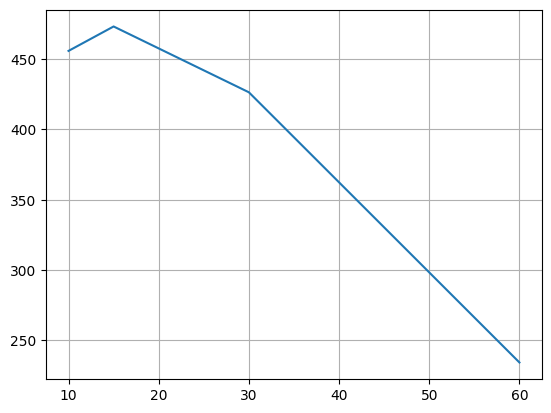

In [14]:
plt.plot(chunksizes, time_taken[:4])
plt.grid(which='both')
plt.show()

In [10]:
input = file_path_mappings[:10]

In [11]:
time_taken_test2 = np.zeros(10)
for i in np.arange(1, 10+1):
    num_processes = 4
    pool = multiprocessing.Pool(processes=num_processes)
    chunks_per_processor = i
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test2[i-1] = end-start

time_taken_test2

Parsing 10 chunks with 4 processors and 1 chunks per processor


Applying BatDetect2: 100%|██████████| 10/10 [04:12<00:00, 25.26s/it]

Time taken: 252.6416094303131s


Parsing 10 chunks with 4 processors and 2 chunks per processor


Applying BatDetect2: 100%|██████████| 10/10 [04:26<00:00, 26.62s/it]

...

Time taken: 40.11854267120361s


Parsing 10 chunks with 4 processors and 10 chunks per processor


Applying BatDetect2: 100%|██████████| 10/10 [00:32<00:00,  3.28s/it]

Time taken: 32.77171087265015s


array([252.64160943, 266.21985364, 180.77797675, 199.23390317,
       119.27655864,  80.16067886,  62.31747317,  56.88904595,
        40.11854267,  32.77171087])

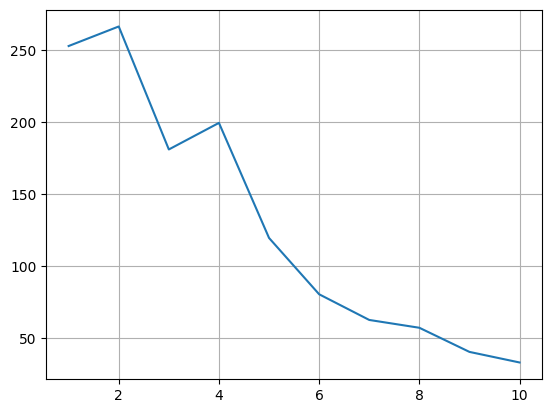

In [12]:
plt.plot(np.arange(1,11,1, dtype=int), time_taken_test2)
plt.grid(which='both')
plt.show()

In [13]:
input = file_path_mappings[:10]

In [14]:
num_processes = 1
pool = multiprocessing.Pool(processes=num_processes)
chunksize_default, extra = divmod(len(input), num_processes*4)
if extra:
    chunksize_default += 1
chunksize_custom = 10
(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')

'Parsing 10 chunks with 1 processors and 10 chunks per processor'

In [15]:
time_taken_test3 = np.zeros(multiprocessing.cpu_count())
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    chunksize_custom = 10
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test3[i] = end-start
time_taken_test3

Parsing 10 chunks with 1 processors and 10 chunks per processor


Applying BatDetect2:   0%|          | 0/10 [00:00<?, ?it/s]

Applying BatDetect2: 100%|██████████| 10/10 [00:30<00:00,  3.06s/it]

Time taken: 30.64318346977234s


Parsing 10 chunks with 2 processors and 10 chunks per processor


...

Time taken: 30.895438194274902s


Parsing 10 chunks with 16 processors and 10 chunks per processor


Applying BatDetect2: 100%|██████████| 10/10 [00:32<00:00,  3.25s/it]

Time taken: 32.519800901412964s


array([30.64318347, 31.35886431, 33.35758781, 32.59960413, 32.15102601,
       32.383075  , 32.26651621, 33.09149075, 30.19781876, 32.67761326,
       32.698035  , 32.25285077, 31.87947965, 31.53046918, 30.89543819,
       32.5198009 ])

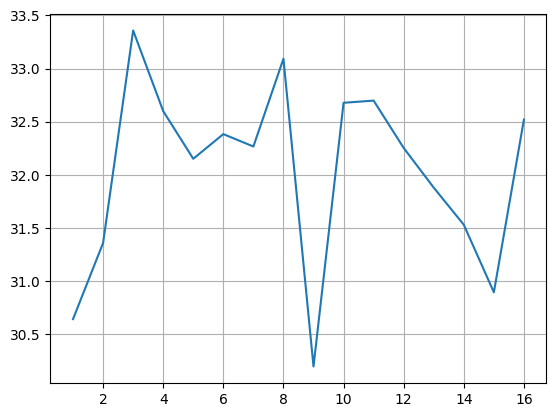

In [16]:
plt.plot(1+np.arange(multiprocessing.cpu_count(), dtype=int), time_taken_test3)
plt.grid(which='both')
plt.show()

In [17]:
input = file_path_mappings[:4]
num_processes = 4
pool = multiprocessing.Pool(processes=num_processes)
chunksize_custom = 4
print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
start = time.time()
results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                desc=f"Applying BatDetect2", total=len(input),)
bd_preds = gen_empty_df() 
bd_preds = pd.concat(results, ignore_index=True)
end = time.time()
print(f'Time taken: {end-start}s')

Parsing 4 chunks with 4 processors and 4 chunks per processor


Applying BatDetect2: 100%|██████████| 4/4 [00:12<00:00,  3.11s/it]

Time taken: 12.44689393043518s


In [18]:
input = file_path_mappings[:1]
time_taken_test3 = np.zeros(multiprocessing.cpu_count())
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    chunksize_custom = 1
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test3[i] = end-start
time_taken_test3

Parsing 1 chunks with 1 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/1 [00:00<?, ?it/s]

Applying BatDetect2: 100%|██████████| 1/1 [00:03<00:00,  3.58s/it]

Time taken: 3.58960223197937s


Parsing 1 chunks with 2 processors and 1 chunks per processor


...

Time taken: 3.829505205154419s


Parsing 1 chunks with 16 processors and 1 chunks per processor


Applying BatDetect2: 100%|██████████| 1/1 [00:03<00:00,  3.82s/it]

Time taken: 3.8269569873809814s


array([3.58960223, 3.81134987, 4.0061903 , 4.1435771 , 4.05234289,
       4.03390956, 4.03033352, 4.00271392, 4.1177547 , 3.97883272,
       3.93708825, 3.98540926, 3.62465048, 3.77382469, 3.82950521,
       3.82695699])

In [ ]:
start = time.time()
run_models(file_path_mappings[:8])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 8/8 [00:26<00:00,  3.27s/it]


Baseline time 26.138050317764282s


In [ ]:
input = file_path_mappings[:8]
time_taken_test3 = np.zeros((multiprocessing.cpu_count(), len(input)))
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    for j in np.arange(len(input)):
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                        desc=f"Applying BatDetect2", total=len(input),)
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test3[i,j] = end-start
        print(time_taken_test3)

Parsing 8 chunks with 1 processors and 1 chunks per processor


Applying BatDetect2: 100%|██████████| 8/8 [00:25<00:00,  3.22s/it]


[[25.77774739  0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0

Applying BatDetect2: 100%|██████████| 8/8 [00:25<00:00,  3.20s/it]


[[25.77774739 25.63324142  0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0

...

Applying BatDetect2: 100%|██████████| 8/8 [01:14<00:00,  9.36s/it]


[[25.77774739 25.63324142 25.41276932 24.91369152 25.7726047  25.41542816
  25.30483961 23.80247879]
 [74.88179231  0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.         

Applying BatDetect2: 100%|██████████| 8/8 [01:14<00:00,  9.27s/it]


[[25.77774739 25.63324142 25.41276932 24.91369152 25.7726047  25.41542816
  25.30483961 23.80247879]
 [74.88179231 74.13117838  0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.        ]
 [ 0.          0.          0.          0.          0.         

Applying BatDetect2:   0%|          | 0/8 [00:00<?, ?it/s]

In [9]:
time_taken_test3

array([[17.73037958, 15.1009233 , 15.39409518, 15.49271464],
       [29.10739136, 28.59308028, 22.96591783, 15.51764441],
       [27.67913699, 26.36472154, 21.23092961, 15.65150023],
       [32.50829864, 27.59496355, 21.20469093, 15.47983503]])

In [ ]:
start = time.time()
run_models(file_path_mappings[:2])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 2/2 [00:08<00:00,  4.11s/it]


Baseline time 8.223963737487793s
Parsing 2 chunks with 1 processors and 1 chunks per processor


In [8]:
input = file_path_mappings[:2]
time_taken_test4 = np.zeros((multiprocessing.cpu_count(), len(input)))
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = int(i+1)
    pool = multiprocessing.Pool(processes=num_processes)
    for j in np.arange(len(input)):
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test4[i,j] = end-start
        print(time_taken_test4)

Parsing 2 chunks with 1 processors and 1 chunks per processor
[[9.06864524 0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]]
Parsing 2 chunks with 1 processors and 2 chunks per processor
[[9.06864524 8.24396753]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]]
Parsing 2 chunks with 2 processors and 1 chunks per processor
[[ 9.06864524  8.24396753]
 [15.28555799  0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Parsing 2 chunks with 2 processors and 2 chunks per processor
[[ 9.06864524  8.24396753]
 [15.28555799  8.00390148]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Parsing 2 chunks with 3 processors and 1 chunks per processor
[[ 9.06864524  8.24396753]
 [15.28555799  8.00390148]
 [14.97951436  0.        ]
 [ 0.          0.        ]]
Parsing 2 chunks with 3 processors and 2 chunks per processor
[[ 9.06864524  8.24396753]
 [15.28555799  8.00390148]
 [14.97951436  8.5072093 ]
 [ 0.          0. 

In [9]:
time_taken_test4

array([[ 9.06864524,  8.24396753],
       [15.28555799,  8.00390148],
       [14.97951436,  8.5072093 ],
       [14.39529443,  8.43054485]])

In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 60.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
bd_preds = pd.DataFrame()

if not cfg['output_dir'].is_dir():
    cfg['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

cfg["csv_filename"] = f"batdetect2_pipeline_{input_file.name.split('.')[0]}"
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
file_path_mappings[:2]

Generating detections for 20220728_080000.WAV


[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_60.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x797978f97bb0>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__60.00_120.00.wav'),
   'offset': 60.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x797978f97bb0>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')}]

In [9]:
start = time.time()
run_models(file_path_mappings[:4])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 4/4 [00:32<00:00,  8.12s/it]


Baseline time 32.50226902961731s
Parsing 4 chunks with 1 processors and 1 chunks per processor


In [8]:
input = file_path_mappings[:2]
time_taken_test5 = np.zeros((4, len(input)))
for i in np.arange(4):
    for j in np.arange(len(input)):
        num_processes = int(i+1)
        pool = multiprocessing.Pool(processes=num_processes)
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test5[i,j] = end-start
        print(time_taken_test5)

Parsing 2 chunks with 1 processors and 1 chunks per processor
[[16.54307842  0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Parsing 2 chunks with 1 processors and 2 chunks per processor
[[16.54307842 16.14780831]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Parsing 2 chunks with 2 processors and 1 chunks per processor
[[16.54307842 16.14780831]
 [29.29773045  0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Parsing 2 chunks with 2 processors and 2 chunks per processor
[[16.54307842 16.14780831]
 [29.29773045 18.13284898]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Parsing 2 chunks with 3 processors and 1 chunks per processor
[[16.54307842 16.14780831]
 [29.29773045 18.13284898]
 [29.33248138  0.        ]
 [ 0.          0.        ]]
Parsing 2 chunks with 3 processors and 2 chunks per processor
[[16.54307842 16.14780831]
 [29.29773045 18.13284898]
 [29.33248138 16.46158862]
 [

In [9]:
time_taken_test5

array([[16.54307842, 16.14780831],
       [29.29773045, 18.13284898],
       [29.33248138, 16.46158862],
       [28.86672378, 16.3100605 ]])